<a href="https://colab.research.google.com/github/EverHernandez01/Teoria_de_se-ales/blob/main/DetectorDeSe%C3%B1ales/RedNeuronal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deteccion de Senales Binarias con Red Neuronal
---
**Referencia teorica**: `02_SignalDetection.pdf` (Signal Detection Theory)

**Objetivo**: Reemplazar el detector clasico de Bayes (umbral fijo) por una red neuronal
que aprenda la frontera de decision directamente de los datos.

**Modelo del canal**: $y(t) = x(a_n, t) + \eta(t)$, donde $\eta \sim \mathcal{N}(0,\sigma^2)$

**Simbolos**: $a_0 = -2V$ (`0` logico), $a_1 = +2V$ (`1` logico)

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import numpy as np
import math
from scipy.special import erfc
import scipy.stats
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.colors import ListedColormap

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURACION DE PLOTS
# ============================================================
rcParams['figure.figsize'] = [15, 6]
rcParams['lines.markersize'] = 8
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['figure.dpi'] = 120

In [2]:
# ============================================================
# FUNCION Q (cola de la Gaussiana) — para detector clasico
# ============================================================
def q_function(x):
    """Q(x) = P(Z > x) para Z ~ N(0,1)."""
    return 0.5 * erfc(x / math.sqrt(2))


# ============================================================
# GENERACION DE SIMBOLOS Y SEÑAL (sample-and-hold)
# ============================================================
def generate_symbols(Nsymbols, symbol_values, symbol_probabilities, random_seed=None):
    """Genera secuencia de simbolos aleatorios."""
    if random_seed is not None:
        np.random.seed(int(random_seed))
    return np.random.choice(symbol_values, size=int(Nsymbols), p=symbol_probabilities)


def generate_signal(symbols, Nsamples_por_symbol):
    """Convierte simbolos discretos en senal continua (sample-and-hold)."""
    Nsps = int(Nsamples_por_symbol)
    return np.concatenate([[s] * Nsps for s in symbols])


# ============================================================
# UMBRAL DE BAYES (detector clasico)
# ============================================================
def calcular_umbral_bayes(s0_val, s1_val, noise_std, p0=0.5, p1=0.5):
    """
    Umbral optimo de decision (minima probabilidad de error).
    gamma = (s0 + s1)/2 + (sigma^2/(s1 - s0)) * ln(p0/p1)
    """
    sigma2 = noise_std ** 2
    mid_point = (s0_val + s1_val) / 2.0
    if p1 > 0 and p0 > 0:
        correction = (sigma2 / (s1_val - s0_val)) * math.log(p0 / p1)
    else:
        correction = 0.0
    return mid_point + correction


def probabilidad_error_teorica(s0_val, s1_val, noise_std, gamma, p0=0.5, p1=0.5):
    """
    Calcula P(1|0), P(0|1) y P(error) teoricas.
    P(1|0) = Q((gamma - s0)/sigma)
    P(0|1) = Q((s1 - gamma)/sigma)
    """
    p_1_dado_0 = q_function((gamma - s0_val) / noise_std)
    p_0_dado_1 = q_function((s1_val - gamma) / noise_std)
    pe_total = p0 * p_1_dado_0 + p1 * p_0_dado_1
    return p_1_dado_0, p_0_dado_1, pe_total

In [3]:
# ============================================================
# CREACION DEL DATASET DE ENTRENAMIENTO
# ============================================================
def crear_dataset(n_realizaciones=200, Nsymbols=128, Nsps=32,
                  symbol_values=None, symbol_probs=None,
                  noise_variance=1.0, base_seed=0):
    """
    Genera el dataset para entrenar la red neuronal.

    Cada muestra es una ventana de Nsps muestras de la senal recibida.
    La etiqueta es el simbolo original (0 o 1).

    Parametros:
    -----------
    n_realizaciones : numero de simulaciones independientes
    Nsymbols        : simbolos por realizacion
    Nsps            : muestras por simbolo (dimension de entrada)
    symbol_values   : [s0, s1] valores de los simbolos
    symbol_probs    : [p(s0), p(s1)] probabilidades a priori
    noise_variance  : varianza del ruido AWGN (sigma^2)
    base_seed       : semilla base (incrementada por realizacion)

    Retorna:
    --------
    X : ndarray de forma (n_muestras, Nsps) — ventanas de senal recibida
    y : ndarray de forma (n_muestras,)       — etiquetas 0/1
    """
    if symbol_values is None:
        symbol_values = [-2, 2]
    if symbol_probs is None:
        symbol_probs = [0.5, 0.5]

    X_list, y_list = [], []
    noise_std = math.sqrt(noise_variance)

    for r in range(n_realizaciones):
        seed = base_seed + r
        symbols = generate_symbols(Nsymbols, symbol_values, symbol_probs, seed)
        signal_clean = generate_signal(symbols, Nsps)

        np.random.seed(seed + 10000)
        noise = np.random.normal(0, noise_std, Nsymbols * Nsps)
        received = signal_clean + noise

        ventanas = received.reshape(Nsymbols, Nsps)
        etiquetas = np.where(symbols == symbol_values[1], 1, 0)

        X_list.append(ventanas)
        y_list.append(etiquetas)

    X = np.vstack(X_list)
    y = np.hstack(y_list)
    return X, y


# ============================================================
# GENERAR DATASETS A DIFERENTES SNRs
# ============================================================
def generar_datasets_snr(snr_list_dB, n_realizaciones=200, Nsymbols=128, Nsps=32,
                         symbol_values=None, symbol_probs=None, base_seed=0):
    """
    Genera datasets para cada SNR en la lista.

    SNR_dB = 10*log10(E_s / sigma^2)
    donde E_s = energia promedio por simbolo = p0*s0^2 + p1*s1^2

    Retorna:
    --------
    datasets : dict {snr_dB: (X, y)}
    noise_stds : dict {snr_dB: sigma}
    """
    if symbol_values is None:
        symbol_values = [-2, 2]
    if symbol_probs is None:
        symbol_probs = [0.5, 0.5]

    E_s = symbol_probs[0] * symbol_values[0]**2 + symbol_probs[1] * symbol_values[1]**2

    datasets = {}
    noise_stds = {}

    for snr_dB in snr_list_dB:
        snr_linear = 10 ** (snr_dB / 10.0)
        noise_var = E_s / snr_linear
        noise_std = math.sqrt(noise_var)
        noise_stds[snr_dB] = noise_std

        X, y = crear_dataset(n_realizaciones=n_realizaciones,
                            Nsymbols=Nsymbols, Nsps=Nsps,
                            symbol_values=symbol_values,
                            symbol_probs=symbol_probs,
                            noise_variance=noise_var,
                            base_seed=base_seed + int(snr_dB * 1000))
        datasets[snr_dB] = (X, y)

    return datasets, noise_stds

In [4]:
# ============================================================
# PARAMETROS DEL SISTEMA
# ============================================================
SYMBOL_VALUES = [-2, 2]          # s0 = -2V (bit 0), s1 = +2V (bit 1)
SYMBOL_PROBS  = [0.5, 0.5]       # equiprobables
Nsps          = 32               # muestras por simbolo (dimension de entrada)
Nsymbols      = 128              # simbolos por realizacion
N_REALIZACIONES = 300            # numero de realizaciones para el dataset

s0_val, s1_val = SYMBOL_VALUES
E_s = SYMBOL_PROBS[0]*s0_val**2 + SYMBOL_PROBS[1]*s1_val**2

print(f"Simbolos: s0 = {s0_val} V,  s1 = {s1_val} V")
print(f"Probabilidades a priori: p0 = {SYMBOL_PROBS[0]}, p1 = {SYMBOL_PROBS[1]}")
print(f"Energia promedio por simbolo: E_s = {E_s:.2f}")
print(f"Muestras por simbolo (input dim): {Nsps}")

Simbolos: s0 = -2 V,  s1 = 2 V
Probabilidades a priori: p0 = 0.5, p1 = 0.5
Energia promedio por simbolo: E_s = 4.00
Muestras por simbolo (input dim): 32


In [5]:
# ============================================================
# GENERAR DATASET UNICO (SNR fijo)
# ============================================================
SNR_TARGET_DB = 6.0               # SNR objetivo en dB
snr_linear = 10 ** (SNR_TARGET_DB / 10.0)
noise_var_target = E_s / snr_linear
noise_std_target = math.sqrt(noise_var_target)

print(f"SNR objetivo: {SNR_TARGET_DB} dB")
print(f"Varianza de ruido: sigma^2 = {noise_var_target:.4f}")
print(f"Desviacion estandar: sigma = {noise_std_target:.4f}")
print(f"\nGenerando dataset...")

X, y = crear_dataset(n_realizaciones=N_REALIZACIONES,
                     Nsymbols=Nsymbols, Nsps=Nsps,
                     symbol_values=SYMBOL_VALUES,
                     symbol_probs=SYMBOL_PROBS,
                     noise_variance=noise_var_target,
                     base_seed=0)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Distribucion de clases: 0 -> {np.sum(y==0)} ({100*np.sum(y==0)/len(y):.1f}%),"
      f" 1 -> {np.sum(y==1)} ({100*np.sum(y==1)/len(y):.1f}%)")

SNR objetivo: 6.0 dB
Varianza de ruido: sigma^2 = 1.0048
Desviacion estandar: sigma = 1.0024

Generando dataset...
X shape: (38400, 32)
y shape: (38400,)
Distribucion de clases: 0 -> 19214 (50.0%), 1 -> 19186 (50.0%)


In [6]:
# ============================================================
# PREPROCESAMIENTO: normalizacion y split train/val/test
# ============================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Val:   {X_val.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")

Train: 26880 muestras
Val:   5760 muestras
Test:  5760 muestras


In [7]:
# ============================================================
# CONSTRUCCION DE LA RED NEURONAL (MLP)
# ============================================================
# Arquitectura:
#   Entrada      : 32 neuronas (Nsps muestras por simbolo)
#   Capa oculta 1: 64 neuronas + ReLU
#   Capa oculta 2: 32 neuronas + ReLU
#   Capa oculta 3: 16 neuronas + ReLU
#   Salida       : 2 neuronas + Softmax  (clasificacion binaria)

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    activation='relu',
    solver='adam',
    alpha=1e-4,                # regularizacion L2
    batch_size=256,
    learning_rate_init=0.001,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=42,
    verbose=True
)

print("Arquitectura de la red:")
print("  Input  : 32 neuronas (ventana de simbolo)")
print("  Hidden : 64 -> 32 -> 16 (ReLU)")
print("  Output : 2 neuronas (Softmax)")
print(f"\n  Total de capas ocultas: {len(mlp.hidden_layer_sizes)}")
print(f"  Optimizador: Adam")
print(f"  Funcion de perdida: Cross-Entropy")

Arquitectura de la red:
  Input  : 32 neuronas (ventana de simbolo)
  Hidden : 64 -> 32 -> 16 (ReLU)
  Output : 2 neuronas (Softmax)

  Total de capas ocultas: 3
  Optimizador: Adam
  Funcion de perdida: Cross-Entropy


In [8]:
# ============================================================
# ENTRENAMIENTO
# ============================================================
print("Entrenando red neuronal...\n")
mlp.fit(X_train, y_train)

print(f"\nEntrenamiento finalizado.")
print(f"Iteraciones ejecutadas: {mlp.n_iter_}")
print(f"Perdida final (train): {mlp.loss_:.6f}")
print(f"Capas de la red: {mlp.n_layers_}")
print(f"Neuronas por capa: {mlp.hidden_layer_sizes}")

Entrenando red neuronal...

Iteration 1, loss = 0.09528886
Validation score: 1.000000
Iteration 2, loss = 0.00069693
Validation score: 1.000000
Iteration 3, loss = 0.00029482
Validation score: 1.000000
Iteration 4, loss = 0.00016798
Validation score: 1.000000
Iteration 5, loss = 0.00011251
Validation score: 1.000000
Iteration 6, loss = 0.00008355
Validation score: 1.000000
Iteration 7, loss = 0.00006655
Validation score: 1.000000
Iteration 8, loss = 0.00005573
Validation score: 1.000000
Iteration 9, loss = 0.00004841
Validation score: 1.000000
Iteration 10, loss = 0.00004325
Validation score: 1.000000
Iteration 11, loss = 0.00003946
Validation score: 1.000000
Iteration 12, loss = 0.00003661
Validation score: 1.000000
Iteration 13, loss = 0.00003442
Validation score: 1.000000
Iteration 14, loss = 0.00003269
Validation score: 1.000000
Iteration 15, loss = 0.00003129
Validation score: 1.000000
Iteration 16, loss = 0.00003015
Validation score: 1.000000
Iteration 17, loss = 0.00002922
Valid

In [9]:
# ============================================================
# EVALUACION EN TEST
# ============================================================
from sklearn.metrics import accuracy_score

y_pred_train = mlp.predict(X_train)
y_pred_val = mlp.predict(X_val)
y_pred_test = mlp.predict(X_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_val = accuracy_score(y_val, y_pred_val)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Accuracy Train : {acc_train:.4f}")
print(f"Accuracy Val   : {acc_val:.4f}")
print(f"Accuracy Test  : {acc_test:.4f}")

print("\nMatriz de confusion (Test):")
cm = confusion_matrix(y_test, y_pred_test)
print(f"              Predicho 0  Predicho 1")
print(f"Real 0        {cm[0,0]:>10}  {cm[0,1]:>10}")
print(f"Real 1        {cm[1,0]:>10}  {cm[1,1]:>10}")

# Probabilidades de error empiricas de la red
p_1_dado_0_nn = cm[0, 1] / (cm[0, 0] + cm[0, 1]) if (cm[0, 0] + cm[0, 1]) > 0 else 0
p_0_dado_1_nn = cm[1, 0] / (cm[1, 0] + cm[1, 1]) if (cm[1, 0] + cm[1, 1]) > 0 else 0
pe_nn = (cm[0, 1] + cm[1, 0]) / cm.sum()

print(f"\nProbabilidades de error — Red Neuronal (empiricas):")
print(f"  P(1|0) = P(decidir 1 | envio 0) = {p_1_dado_0_nn:.6f}")
print(f"  P(0|1) = P(decidir 0 | envio 1) = {p_0_dado_1_nn:.6f}")
print(f"  P(error total)                  = {pe_nn:.6f}")

Accuracy Train : 1.0000
Accuracy Val   : 1.0000
Accuracy Test  : 1.0000

Matriz de confusion (Test):
              Predicho 0  Predicho 1
Real 0              2882           0
Real 1                 0        2878

Probabilidades de error — Red Neuronal (empiricas):
  P(1|0) = P(decidir 1 | envio 0) = 0.000000
  P(0|1) = P(decidir 0 | envio 1) = 0.000000
  P(error total)                  = 0.000000


In [10]:
# ============================================================
# COMPARACION CON DETECTOR CLASICO DE BAYES
# ============================================================
gamma_bayes = calcular_umbral_bayes(s0_val, s1_val, noise_std_target,
                                     p0=SYMBOL_PROBS[0], p1=SYMBOL_PROBS[1])
p10_teo, p01_teo, pe_teo = probabilidad_error_teorica(
    s0_val, s1_val, noise_std_target, gamma_bayes,
    p0=SYMBOL_PROBS[0], p1=SYMBOL_PROBS[1])

print(f"Umbral de Bayes: gamma = {gamma_bayes:.4f}")
print(f"\n{'='*60}")
print(f"  COMPARACION: Detector Clasico vs Red Neuronal")
print(f"{'='*60}")
print(f"  SNR = {SNR_TARGET_DB} dB,  sigma = {noise_std_target:.4f}")
print(f"{'='*60}")
print(f"  Metrica          |  Bayes (teorico)  |  Red Neuronal (empirica)")
print(f"  {'-'*55}")
print(f"  P(1|0)           |  {p10_teo:.6f}         |  {p_1_dado_0_nn:.6f}")
print(f"  P(0|1)           |  {p01_teo:.6f}         |  {p_0_dado_1_nn:.6f}")
print(f"  P(error total)   |  {pe_teo:.6f}         |  {pe_nn:.6f}")
print(f"{'='*60}")

if abs(pe_nn - pe_teo) < 0.01:
    print("\n  >> La red neuronal IGUALA practicamente al detector optimo de Bayes.")
elif pe_nn < pe_teo + 0.02:
    print("\n  >> La red neuronal se APROXIMA al detector optimo de Bayes.")
else:
    print("\n  >> La red neuronal aun tiene margen de mejora.")

Umbral de Bayes: gamma = 0.0000

  COMPARACION: Detector Clasico vs Red Neuronal
  SNR = 6.0 dB,  sigma = 1.0024
  Metrica          |  Bayes (teorico)  |  Red Neuronal (empirica)
  -------------------------------------------------------
  P(1|0)           |  0.023007         |  0.000000
  P(0|1)           |  0.023007         |  0.000000
  P(error total)   |  0.023007         |  0.000000

  >> La red neuronal se APROXIMA al detector optimo de Bayes.


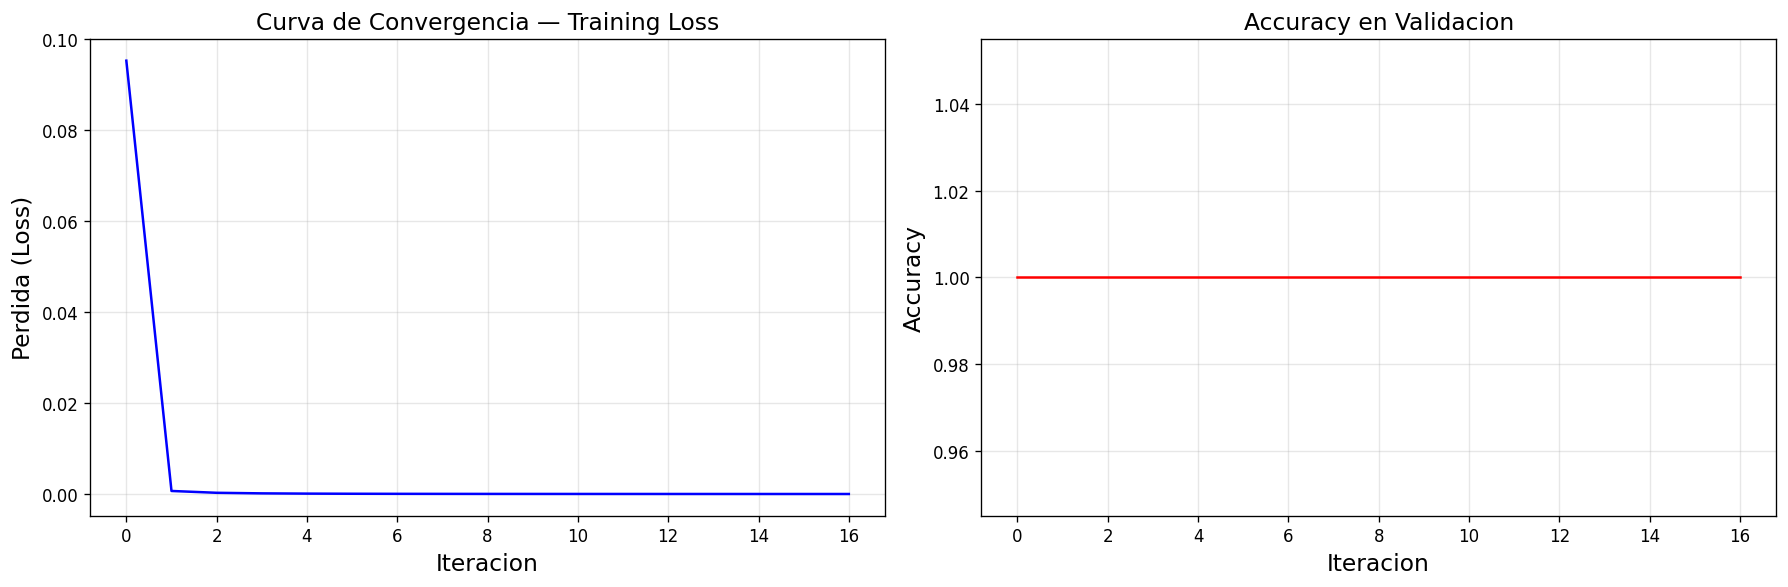

In [11]:
# ============================================================
# VISUALIZACION 1: Curva de perdida durante entrenamiento
# ============================================================
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(mlp.loss_curve_, 'b-', linewidth=1.5)
ax[0].set_xlabel('Iteracion')
ax[0].set_ylabel('Perdida (Loss)')
ax[0].set_title('Curva de Convergencia — Training Loss')
ax[0].grid(True, alpha=0.3)

if hasattr(mlp, 'validation_scores_') and len(mlp.validation_scores_) > 0:
    ax[1].plot(mlp.validation_scores_, 'r-', linewidth=1.5)
    ax[1].set_xlabel('Iteracion')
    ax[1].set_ylabel('Accuracy')
    ax[1].set_title('Accuracy en Validacion')
    ax[1].grid(True, alpha=0.3)
else:
    ax[1].text(0.5, 0.5, 'Sin curva de validacion\n(early stopping activado)',
               transform=ax[1].transAxes, ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.show()

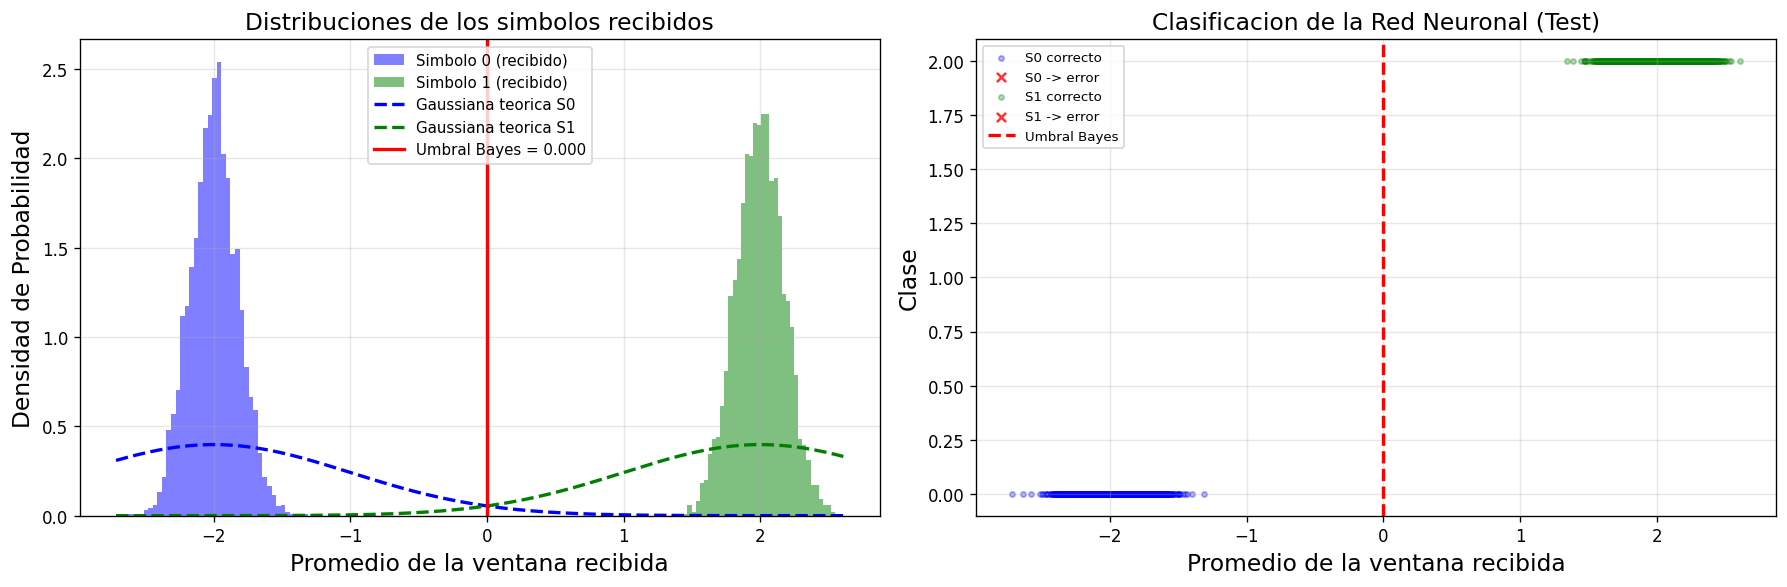

In [12]:
# ============================================================
# VISUALIZACION 2: Distribuciones y frontera de decision
# ============================================================
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Subplot izquierdo: Distribuciones de los promedios por simbolo
X_test_raw = scaler.inverse_transform(X_test)
promedios_test = X_test_raw.mean(axis=1)

promedios_0 = promedios_test[y_test == 0]
promedios_1 = promedios_test[y_test == 1]

bins = int(1 + 3.322 * np.log2(len(promedios_test)))
ax[0].hist(promedios_0, bins=bins, density=True, alpha=0.5, color='blue',
           label='Simbolo 0 (recibido)')
ax[0].hist(promedios_1, bins=bins, density=True, alpha=0.5, color='green',
           label='Simbolo 1 (recibido)')

x_range = np.linspace(min(promedios_test), max(promedios_test), 200)
ax[0].plot(x_range, scipy.stats.norm.pdf(x_range, s0_val, noise_std_target),
           'b--', linewidth=2, label='Gaussiana teorica S0')
ax[0].plot(x_range, scipy.stats.norm.pdf(x_range, s1_val, noise_std_target),
           'g--', linewidth=2, label='Gaussiana teorica S1')
ax[0].axvline(x=gamma_bayes, color='red', linestyle='-', linewidth=2,
              label=f'Umbral Bayes = {gamma_bayes:.3f}')
ax[0].set_xlabel('Promedio de la ventana recibida')
ax[0].set_ylabel('Densidad de Probabilidad')
ax[0].set_title('Distribuciones de los simbolos recibidos')
ax[0].legend(fontsize=9)
ax[0].grid(True, alpha=0.3)

# Subplot derecho: Predicciones correctas vs incorrectas
correctos = y_pred_test == y_test
incorrectos = ~correctos

ax[1].scatter(promedios_test[correctos & (y_test == 0)],
              np.zeros(np.sum(correctos & (y_test == 0))),
              c='blue', alpha=0.3, s=10, label='S0 correcto')
ax[1].scatter(promedios_test[incorrectos & (y_test == 0)],
              np.ones(np.sum(incorrectos & (y_test == 0))),
              c='red', alpha=0.8, s=30, marker='x', label='S0 -> error')
ax[1].scatter(promedios_test[correctos & (y_test == 1)],
              np.ones(np.sum(correctos & (y_test == 1))) * 2,
              c='green', alpha=0.3, s=10, label='S1 correcto')
ax[1].scatter(promedios_test[incorrectos & (y_test == 1)],
              np.ones(np.sum(incorrectos & (y_test == 1))) * 3,
              c='red', alpha=0.8, s=30, marker='x', label='S1 -> error')

ax[1].axvline(x=gamma_bayes, color='red', linestyle='--', linewidth=2,
              label=f'Umbral Bayes')
ax[1].set_xlabel('Promedio de la ventana recibida')
ax[1].set_ylabel('Clase')
ax[1].set_title('Clasificacion de la Red Neuronal (Test)')
ax[1].legend(fontsize=8)
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Evaluando a multiples SNRs...
  SNR =  -4 dB  |  P(e) Bayes = 0.264034  |  P(e) Red = 0.001250
  SNR =  -2 dB  |  P(e) Bayes = 0.213502  |  P(e) Red = 0.000156
  SNR =   0 dB  |  P(e) Bayes = 0.158655  |  P(e) Red = 0.000000
  SNR =   2 dB  |  P(e) Bayes = 0.104029  |  P(e) Red = 0.000000
  SNR =   4 dB  |  P(e) Bayes = 0.056495  |  P(e) Red = 0.000000
  SNR =   6 dB  |  P(e) Bayes = 0.023007  |  P(e) Red = 0.000000
  SNR =   8 dB  |  P(e) Bayes = 0.006004  |  P(e) Red = 0.000000
  SNR =  10 dB  |  P(e) Bayes = 0.000783  |  P(e) Red = 0.000000
  SNR =  12 dB  |  P(e) Bayes = 0.000034  |  P(e) Red = 0.000000


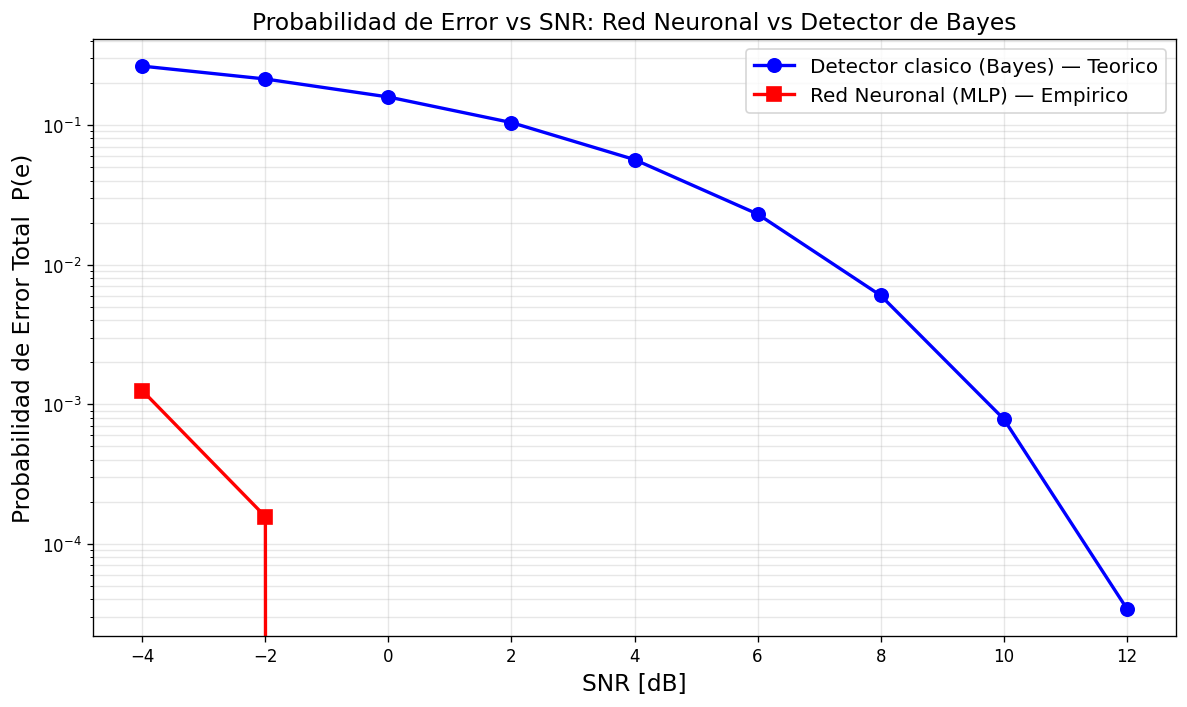

In [13]:
# ============================================================
# VISUALIZACION 3: Error vs SNR (Red vs Bayes)
# ============================================================
snr_range = [-4, -2, 0, 2, 4, 6, 8, 10, 12]
pe_bayes_list = []
pe_nn_list = []

print("Evaluando a multiples SNRs...")
for snr_db in snr_range:
    snr_lin = 10 ** (snr_db / 10.0)
    noise_var = E_s / snr_lin
    noise_std_eval = math.sqrt(noise_var)

    # Detector clasico teorico
    gamma = calcular_umbral_bayes(s0_val, s1_val, noise_std_eval,
                                   p0=SYMBOL_PROBS[0], p1=SYMBOL_PROBS[1])
    _, _, pe_b = probabilidad_error_teorica(s0_val, s1_val, noise_std_eval, gamma,
                                             p0=SYMBOL_PROBS[0], p1=SYMBOL_PROBS[1])
    pe_bayes_list.append(pe_b)

    # Red neuronal: generar datos a este SNR y evaluar
    X_eval, y_eval = crear_dataset(n_realizaciones=50, Nsymbols=128, Nsps=Nsps,
                                    symbol_values=SYMBOL_VALUES,
                                    symbol_probs=SYMBOL_PROBS,
                                    noise_variance=noise_var,
                                    base_seed=99999 + int(snr_db * 1000))
    X_eval_s = scaler.transform(X_eval)
    y_pred_nn = mlp.predict(X_eval_s)
    cm_eval = confusion_matrix(y_eval, y_pred_nn)
    pe_n = (cm_eval[0, 1] + cm_eval[1, 0]) / cm_eval.sum()
    pe_nn_list.append(pe_n)

    print(f"  SNR = {snr_db:>3} dB  |  P(e) Bayes = {pe_b:.6f}  |  P(e) Red = {pe_n:.6f}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogy(snr_range, pe_bayes_list, 'b-o', linewidth=2, markersize=8,
            label='Detector clasico (Bayes) — Teorico')
ax.semilogy(snr_range, pe_nn_list, 'r-s', linewidth=2, markersize=8,
            label='Red Neuronal (MLP) — Empirico')
ax.set_xlabel('SNR [dB]')
ax.set_ylabel('Probabilidad de Error Total  P(e)')
ax.set_title('Probabilidad de Error vs SNR: Red Neuronal vs Detector de Bayes')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()


Visualizando la frontera de decision aprendida...
(Proyectando las 32 dimensiones a 2 componentes principales)


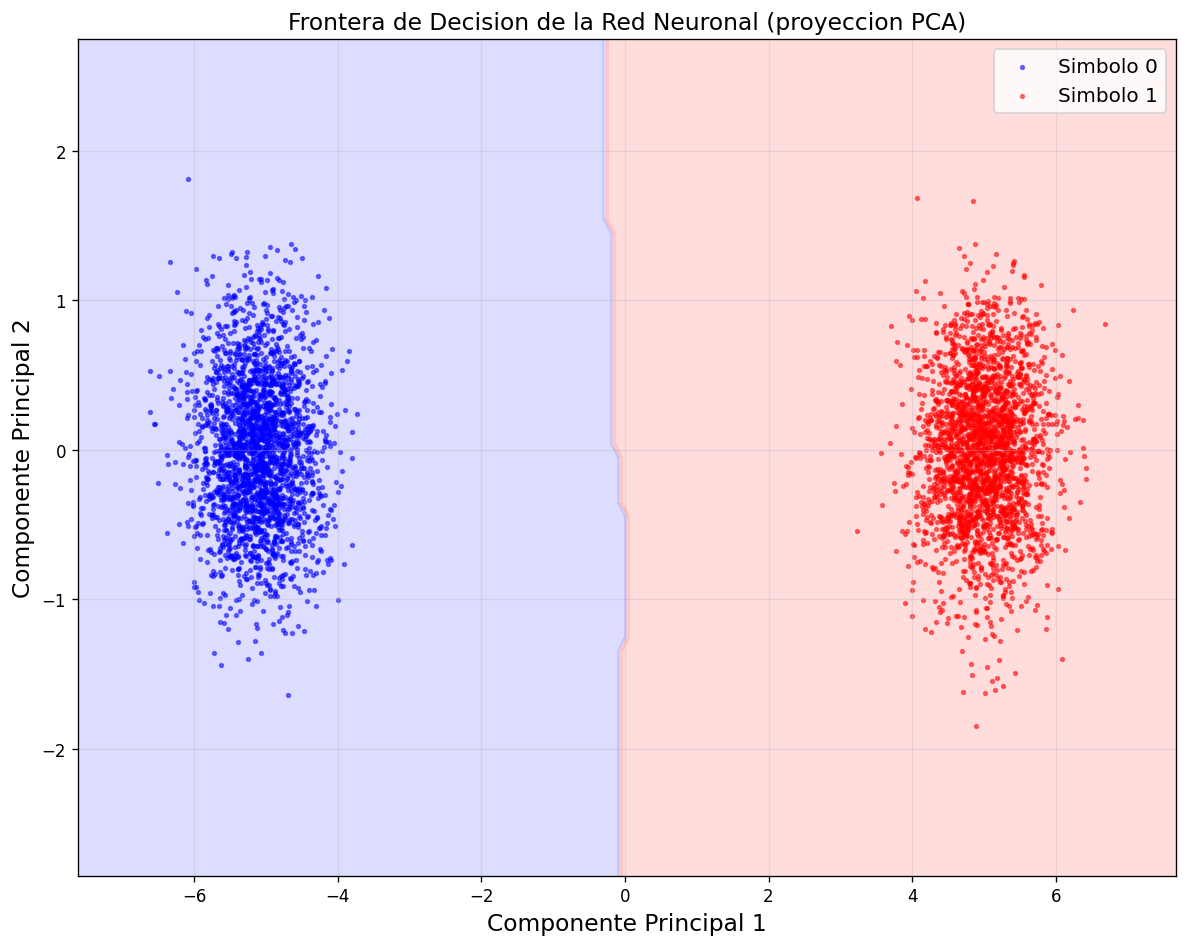

Varianza explicada por PCA: PC1=80.52%, PC2=0.73%


In [14]:
# ============================================================
# VISUALIZACION 4: Mapa de decision de la red
# ============================================================
print("\nVisualizando la frontera de decision aprendida...")
print("(Proyectando las 32 dimensiones a 2 componentes principales)")

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled[:5000])

h = 0.1
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

grid_pca = np.c_[xx.ravel(), yy.ravel()]
grid_original = pca.inverse_transform(grid_pca)
Z = mlp.predict(grid_original).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 8))
cmap_light = ListedColormap(['#AAAAFF', '#FFAAAA'])
ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_light)
ax.scatter(X_pca[y[:5000] == 0, 0], X_pca[y[:5000] == 0, 1],
           c='blue', s=5, alpha=0.5, label='Simbolo 0')
ax.scatter(X_pca[y[:5000] == 1, 0], X_pca[y[:5000] == 1, 1],
           c='red', s=5, alpha=0.5, label='Simbolo 1')
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.set_title('Frontera de Decision de la Red Neuronal (proyeccion PCA)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Varianza explicada por PCA: PC1={pca.explained_variance_ratio_[0]:.2%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.2%}")

In [15]:
# ============================================================
# RESUMEN FINAL
# ============================================================
print("\n" + "=" * 65)
print("  RESUMEN DEL SISTEMA DE DETECCION CON RED NEURONAL")
print("=" * 65)
print(f"  Arquitectura:       MLP ({Nsps}, 64, 32, 16, 2)")
print(f"  Funcion activacion: ReLU + Softmax")
print(f"  Optimizador:        Adam (lr=0.001)")
print(f"  Perdida:            Cross-Entropy")
print(f"  Muestras entreno:   {X_train.shape[0]}")
print(f"  Muestras test:      {X_test.shape[0]}")
print(f"  SNR entrenamiento:  {SNR_TARGET_DB} dB")
print(f"  Accuracy test:      {acc_test*100:.2f}%")
print(f"  P(e) Red vs Bayes:  {pe_nn:.6f} vs {pe_teo:.6f}")
print("=" * 65)
print("\n  >> La red neuronal aprende implicitamente la frontera")
print("     de decision sin necesidad de umbral explicito ni")
print("     conocimiento previo de la distribucion del ruido.")
print("=" * 65)


  RESUMEN DEL SISTEMA DE DETECCION CON RED NEURONAL
  Arquitectura:       MLP (32, 64, 32, 16, 2)
  Funcion activacion: ReLU + Softmax
  Optimizador:        Adam (lr=0.001)
  Perdida:            Cross-Entropy
  Muestras entreno:   26880
  Muestras test:      5760
  SNR entrenamiento:  6.0 dB
  Accuracy test:      100.00%
  P(e) Red vs Bayes:  0.000000 vs 0.023007

  >> La red neuronal aprende implicitamente la frontera
     de decision sin necesidad de umbral explicito ni
     conocimiento previo de la distribucion del ruido.
